In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from fontTools.merge import cmap
from matplotlib.pyplot import subplot

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from dfmodel import DigitalFamilyBinary

In [2]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [5]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [6]:
training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])


In [7]:
training_data[clinical_columns]

,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,crp_day1,trc_emergency_department,sex,age
0,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,-2.677143e-16,-0.345625,-0.906163,1.0,-2.365415
1,-1.577464,-0.128251,0.216787,0.322727,1.041185,1.0,-1.451047,-0.037510,-2.677143e-16,-0.434355,1.385753,0.0,-0.075467
2,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,-2.677143e-16,0.679707,0.384794,1.0,-0.155328
3,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,-2.677143e-16,1.665603,-0.859389,0.0,1.115809
4,-0.213116,-1.597408,-1.611235,0.394841,1.940465,1.0,-3.109139,-0.188534,-8.225653e-01,-0.953922,0.160279,0.0,-2.188787
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,-2.677143e-16,-0.158304,3.874118,1.0,0.295378
676,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,3.077577e-01,-0.808996,0.712210,0.0,0.009216
677,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,-2.197263e-01,-0.345625,1.900264,1.0,0.058323
678,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,-5.965007e-01,-0.207599,0.188344,0.0,0.413090


<Axes: >

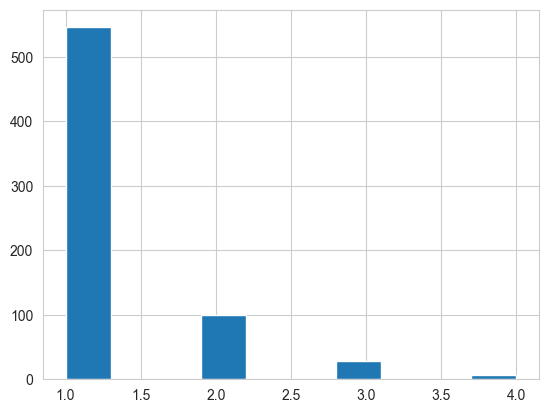

In [8]:
training_data["mental_status_ambulance"].hist()

In [9]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean")

In [10]:
df_estimator.fit(training_data, features=clinical_columns)

In [11]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=clinical_columns, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=clinical_columns, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=clinical_columns, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=clinical_columns, target_column="survival_30_day", bootstrap=False)

In [12]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


In [44]:
positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [45]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
]

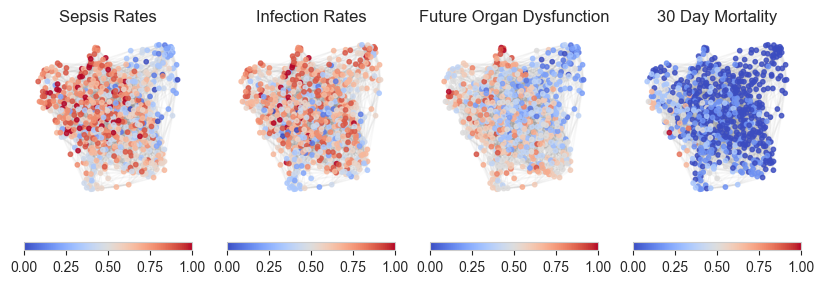

In [95]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

In [96]:
fig.savefig(
    "diagnosis_prognosis_maps.pdf", dpi=300, bbox_inches="tight"
)

In [81]:
training_data.sort_values('30 Day Mortality', ascending=False)

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,survival_30_day,future_deterioration,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality,mortality_30_day
130,130,SA_BOX_6-2233_S2-E8_1_5870,-2.487029,1.096046,0.739079,-1.083497,-1.678066,1.0,-1.743651,1.008871,...,0.0,0.0,NaN,1,0,0.8,0.7,0.5,0.6,1
475,475,SA_BOX_13-377_S1-G1_1_6502,-4.419854,2.320344,0.347360,-0.722927,-0.179266,1.0,-0.768303,0.577374,...,0.0,0.0,0.0,0,1,0.9,0.7,0.9,0.5,0
535,535,SA_BOX_13-2283_S1-G5_1_6534,-3.282898,2.075484,-0.044359,-1.804637,-2.919928,4.0,1.377463,1.181470,...,0.0,0.0,0.0,0,1,1.0,0.9,0.6,0.5,0
73,73,SA_BOX_13-2658_S1-A2_1_6504,-1.918551,0.606327,0.129738,0.178498,0.000000,1.0,-0.183094,-0.199321,...,0.0,0.0,NaN,1,1,1.0,0.8,0.7,0.5,1
462,462,SA_BOX_11-818_S4-B11_1_6382,-0.326812,-0.617970,0.347360,-1.263782,0.000000,1.0,-0.670768,-0.059085,...,0.0,0.0,0.0,0,1,0.8,0.8,0.7,0.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,151,SA_BOX_6-2365_S2-H6_1_5856,-0.554203,0.116608,1.043750,1.512608,2.261636,1.0,0.109510,-0.630818,...,0.0,0.0,0.0,0,1,0.4,0.9,0.2,0.0,0
152,152,SA_BOX_7-26_S4-H4_1_5938,-0.099421,-0.250681,0.129738,-1.083497,0.000000,2.0,1.572533,-0.436645,...,0.0,0.0,0.0,0,1,0.8,0.8,0.6,0.0,0
380,380,SA_BOX_12-2462_S5-B11_1_6480,-0.326812,-0.128251,-1.393613,-0.542642,0.000000,1.0,0.889789,-0.253258,...,0.0,0.0,0.0,0,1,0.8,0.7,0.4,0.0,0
378,378,SA_BOX_1-2438_S1-D3_1_6808,1.037535,-1.230119,1.391944,-0.939269,-0.778786,1.0,0.402115,-0.317983,...,0.0,0.0,0.0,0,0,0.3,0.2,0.4,0.0,0


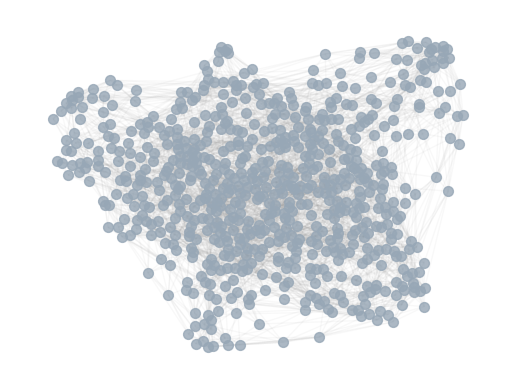

In [101]:


nx.draw_networkx_nodes(G, positions, node_size=50, node_color="#97A7B6", alpha=0.8)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05)
plt.axis('off')
plt.savefig(
    "overall_map.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

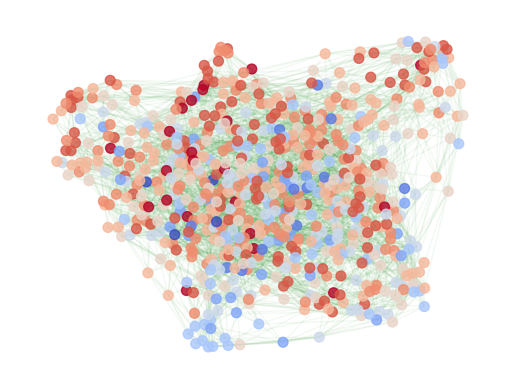

In [73]:
color_map = dict(zip(training_data.index, training_data['Infection Rates']))

node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, cmap="coolwarm")
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

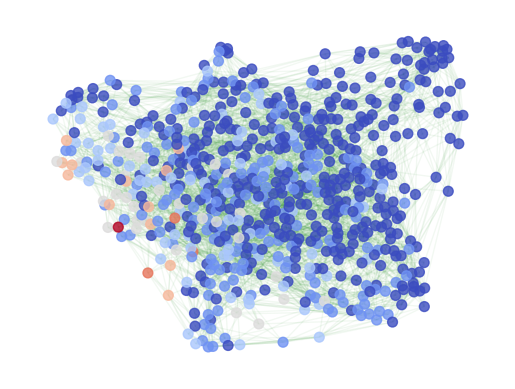

In [74]:
color_map = dict(zip(training_data.index, training_data['30 Day Mortality']))

node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, cmap="coolwarm")
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

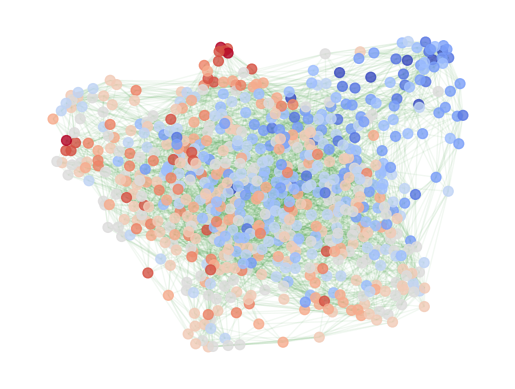

In [75]:
color_map = dict(zip(training_data.index, training_data['Future Organ Dysfunction']))

node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, cmap="coolwarm")
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

In [41]:
training_data['mortality_30_day'] = np.where(training_data['survival_days'] <= 30, 1, 0)

In [14]:
training_data['mortality_30_day'].value_counts()

mortality_30_day
0    611
1     69
Name: count, dtype: int64

In [15]:

color_map = dict(zip(training_data.index, training_data['sex']))

node_colors = [color_map[node] for node in G.nodes()]


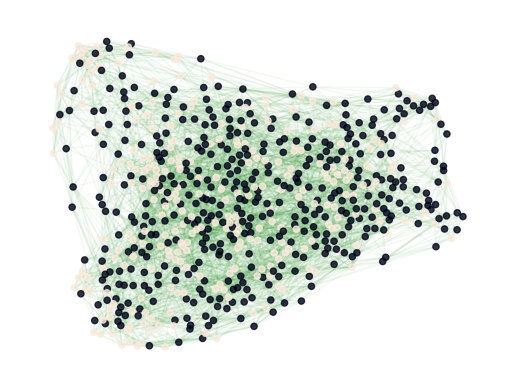

In [16]:
nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, alpha=0.8,)
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

In [52]:
for idx, data in testing_data.iterrows():

    sample_graph = df_estimator.model_sample(data, clinical_columns)

In [17]:
sample_graph

In [18]:
X_ = training_data.copy()
X_['source'] = "base"
X_['size'] = 20

test = pd.DataFrame([data])
test['source'] = "query"
test['size'] = 100

In [19]:
combined_data = pd.concat(
    [X_, test], ignore_index=True
)

In [20]:
combined_data.tail()

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_coag_day3,sofa_cns_day1,sofa_cns_day2,sofa_cns_day3,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,mortality_30_day,source,size
676,676,SA_BOX_3-697_S4-A6_1_5555,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,base,20
677,677,SA_BOX_8-2367_S5-C12_1_6096,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
678,678,SA_BOX_4-2564_S5-F11_1_5699,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
679,679,SA_BOX_10-131_S2-H6_1_6249,-0.440508,0.116608,-0.131408,-0.903212,0.000000,1.0,1.182393,-0.253258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,base,20
680,679,SA_BOX_4-1196_S5-A2_1_5621,0.469057,0.116608,-0.784273,3.063060,2.925391,1.0,0.597184,-0.156171,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,query,100


In [21]:
nx.set_node_attributes(sample_graph, combined_data.to_dict(orient="index"))

In [22]:
sample_graph.nodes[0]

{'Unnamed: 0': 0,
 'injection': 'SA_BOX_1-462_S1-C8_1_6848',
 'sao2_ambulance': -0.44050753352931954,
 'resp_frequency_ambulance': -0.8628294945851923,
 'heart_rate_ambulance': 0.34736017417729576,
 'syst_bp_ambulance': -0.18207167917904263,
 'map_ambulance': 0.2703738643250759,
 'mental_status_ambulance': 1.0,
 'temperature_ambulance': 0.6947192322208972,
 'crea_emergency_department': -0.5553062518845568,
 'bili_emergency_department': -2.6771426586197504e-16,
 'crp_day1': -0.34562459386468325,
 'trc_emergency_department': -0.9061630549118384,
 'sex': 2.0,
 'age': -2.3654152369787647,
 'diagnosis_sepsis_student_3': 4.0,
 'sepsis_or_septic_shock': 1.0,
 'survival_days': nan,
 'sofa_score_increase_day1': 2.0,
 'sofa_score_increase_day2': nan,
 'sofa_score_increase_day3': nan,
 'verified_infection': 1.0,
 'no_infection': 0.0,
 'irrelevante_bacteremia': 0.0,
 'blood_culture_positive': 0.0,
 'urinary_tract_infection': 0.0,
 'abdominal_infection': 0.0,
 'pseud_blood_culture': 0.0,
 'k_pneu_b

100%|██████████| 1000/1000 [00:01<00:00, 565.66it/s]

BarnesHut Approximation  took  0.41  seconds
Repulsion forces  took  1.16  seconds
Gravitational forces  took  0.02  seconds
Attraction forces  took  0.01  seconds
AdjustSpeedAndApplyForces step  took  0.10  seconds


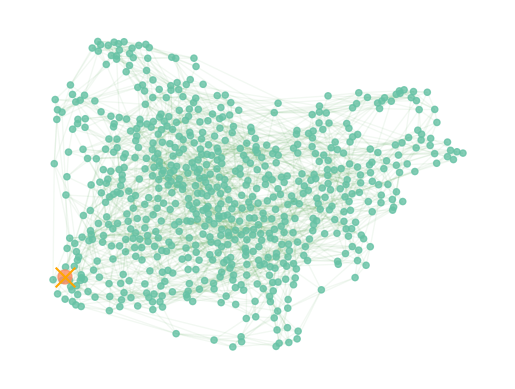

In [23]:
forceatlas2 = ForceAtlas2(
                        # Behavior alternatives
                        outboundAttractionDistribution=True,  # Dissuade hubs
                        linLogMode=False,  # NOT IMPLEMENTED
                        adjustSizes=False,  # Prevent overlap (NOT IMPLEMENTED)
                        edgeWeightInfluence=1.0,

                        # Performance
                        jitterTolerance=1.0,  # Tolerance
                        barnesHutOptimize=True,
                        barnesHutTheta=1.2,
                        multiThreaded=False,  # NOT IMPLEMENTED

                        # Tuning
                        scalingRatio=2.0,
                        strongGravityMode=False,
                        gravity=1.0,

                        # Log
                        verbose=True)

categories = combined_data['source'].unique()
palette = sns.color_palette('Set2', n_colors=len(categories))
category_color_map = dict(zip(categories, palette))

node_colors = [category_color_map[sample_graph.nodes[node]['source']] for node in sample_graph.nodes]

positions = forceatlas2.forceatlas2_networkx_layout(sample_graph, pos=None, iterations=1000)
nx.draw_networkx_nodes(sample_graph, positions, node_size=combined_data['size'].to_list(), node_color=node_colors, alpha=0.8)

nx.draw_networkx_nodes(sample_graph, positions,
                       nodelist=[680],
                       node_size=200,
                       node_color='orange',
                       node_shape='x')

nx.draw_networkx_edges(sample_graph, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()